In [45]:
import numpy as np
from numpy import zeros,ones_like
from numpy import tanh,eye,sin
import matplotlib.pyplot as plt 
from matplotlib.pyplot import plot,figure,cla
import time
rng=np.random.default_rng()
rand=rng.random
from zxgj1.llz import clllz1
from zxgj1.validpt import Vpt
from zxgj1.工具 import f变量变形
from zxgj1.下一代储层计算 import c下一代储层计算
vpt=Vpt.vpt3
plt.rcParams.update({'font.size': 6.5})

### 下一代储层计算

In [46]:
xx=np.load('data/llzc7.npz')
ww1,yy=xx['arr_0'],xx['arr_1'][::2]
xx1=yy[1000:15000]
xx2=yy[15000:20000]
suo=np.ceil(np.max(xx1)+1)
xh1=xx1/suo
xh2=xx2/suo

337
337


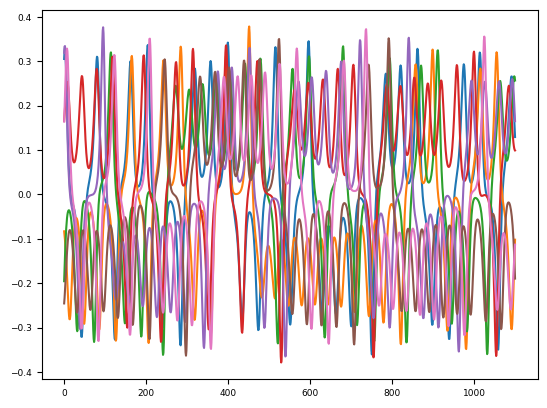

In [47]:
A=c下一代储层计算()
yc1=A.m总程序(xh1,dt=1,grla=10**-6.5)
print(vpt(yc1[100:],xh2,0.5))
figure(1)
plot(yc1[:,::3])

### 单独下一代储层计算

In [48]:
l1,l2=xh1.shape
Sm=int(l2/3)
xh1gai=f变量变形(xh1)
A=[]
yc2=zeros((1100,3*Sm))
for ii in range(Sm):
    A.append(c下一代储层计算())
    yc2[:,ii*3:(ii+1)*3]=A[ii].m总程序(xh1gai[ii],dt=1,grla=1e-6)
vpt(yc2[100:,:],xh2,0.5)
alzhishu=np.arange(-0.5,-9.5,-0.5)
alwhen=10**alzhishu
qstart=100


43


### 改进下一代储层计算

In [49]:
l1,l2=xh1.shape
Sm=int(l2/3)#振子个数
xh1gai=f变量变形(xh1)
cc=[]
for ii in range(Sm):
    zz=[]
    for jj in range(Sm):
        if ww1[ii,jj]>0.01:
            zz.append(jj)
    cc.append(zz)
dLt,dt,start,qstart,grla,n=3,1,80,100,10**-6.5,1000

线性项个数=dLt*3
非线性项个数1=int((线性项个数+1)*线性项个数/2)
非线性项个数2=zeros(Sm,dtype=int)
线性项个数2=zeros(Sm,dtype=int)
for ii in range(Sm):
    线性项个数2[ii]=len(cc[ii])*线性项个数
    非线性项个数2[ii]=线性项个数*len(cc[ii])*线性项个数
总项个数=线性项个数+线性项个数2+非线性项个数1+非线性项个数2+1
RR=[]
for ii in range(Sm):
    RR.append(zeros((l1,总项个数[ii])))
for zz in range(Sm):
    olin=np.c_[xh1gai[zz][start:,:],xh1gai[zz][start-dt:-dt,:],xh1gai[zz][start-2*dt:-2*dt,:]]
    RR[zz][start:,:线性项个数]=olin
for zz in range(Sm):
    xu=线性项个数
    for ij in cc[zz]:
        RR[zz][:,xu:xu+线性项个数]=RR[ij][:,:线性项个数]
        xu=xu+线性项个数
    for ii in range(线性项个数):
        for jj in range(ii,线性项个数):
            RR[zz][start:,xu]=RR[zz][start:,:线性项个数][:,ii]*RR[zz][start:,:线性项个数][:,jj]
            xu=xu+1
    for ii in range(线性项个数):
        for ij in cc[zz]:
            for jj in range(线性项个数):
                RR[zz][:,xu]=RR[zz][:,ii]*RR[ij][:,jj]
                xu=xu+1
    RR[zz][:,xu]=1
qrr=[]
qxx=[]
for ii in range(Sm):
    qrr.append(RR[ii][qstart:-1])
    qxx.append(xh1gai[ii][qstart+1:])
wout=[]  
A=[] 
rrzhong=[]
for ii in range(Sm):
    rrzhong.append(RR[ii][-1].copy())
    A.append(c下一代储层计算())
    wout.append(A[ii].qiujie(qxx[ii],qrr[ii],grla))
n=1000
yc=zeros((Sm,100+n,3))
yc[:,:100]=xh1gai[:,-100:]
xulie=np.triu_indices(线性项个数, k=0, m=None)
# olinhh=zeros((Sm,3*3))
for ii in range(100,100+n):
    for zz in range(Sm):
        yc[zz][ii]=wout[zz]@rrzhong[zz]
    for zz in range(Sm):
        olin=np.r_[yc[zz][ii,:],yc[zz][ii-dt,:],yc[zz][ii-2*dt,:]]
        rrzhong[zz][:线性项个数]=olin
    for zz in range(Sm):
        xu=线性项个数
        for ij in cc[zz]:
            rrzhong[zz][xu:xu+线性项个数]=rrzhong[ij][:线性项个数]
            xu=xu+线性项个数
        for i1 in range(线性项个数):
            for i2 in range(i1,线性项个数):
                rrzhong[zz][xu]=rrzhong[zz][i1]*rrzhong[zz][i2]
                xu=xu+1
        for i1 in range(线性项个数):
            for ij in cc[zz]:
                for jj in range(线性项个数):
                    rrzhong[zz][xu]=rrzhong[zz][i1]*rrzhong[ij][jj]
                    xu=xu+1
        
yct=f变量变形(yc)
print(A[0].wu.max(0),' ', vpt(yct[100:],xh2,0.5))

419
[4.25722022e-06 1.05184926e-04 7.91508400e-05]   419


### 对比图

In [50]:
def hutu11(lwth):
    l1=600
    l2=800
    plt.rcParams.update({'font.size':6.5})
    fig = plt.figure(dpi=300,figsize=(8.5/2.54,6.5/2.54))
    ax1=plt.subplot(4,1,1)
    ax1.plot(yx2[:l1,0],'r',label='actual',linewidth=lwth)
    ax1.plot(ycx1[100:l1+100,0],'b',label='NG-RC',linewidth=lwth)
    ax1.plot(ycx2[100:l1+100,0],'g',label='ING-RC',linewidth=lwth)
    ax1.plot(ycx3[100:l1+100,0],'y',label='SCNG-RC',linewidth=lwth)

    # ax1.set_xlabel('t',labelpad=0)
    ax1.set_ylabel(r'$x_1(t)$',labelpad=-2.5)
    # ax1.set_title("(a),comparison",loc='left')

    ax1.tick_params(axis='both', labelsize=6.5,pad=0.2,length=1)
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1),prop={'size': 6},
            handletextpad=0.5,borderaxespad=0.2,
            labelspacing=0.2,handlelength=1)
    #
    ax2=plt.subplot(4,1,2)
    ax3=plt.subplot(4,1,3)
    ax4=plt.subplot(4,1,4)
    ax2.plot(yx2[:l1,1],'r',label='actual',linewidth=lwth)
    ax2.plot(ycx1[100:l1+100,1],'b',label='NG-RC',linewidth=lwth)
    ax2.plot(ycx2[100:l1+100,1],'g',label='ING-RC',linewidth=lwth)
    ax2.plot(ycx3[100:l1+100,1],'y',label='SCNG-RC',linewidth=lwth)

    ax3.plot(yx2[:l1,2],'r',label='actual',linewidth=lwth)
    ax3.plot(ycx1[100:l1+100,2],'b',label='NG-RC',linewidth=lwth)
    ax3.plot(ycx2[100:l1+100,2],'g',label='ING-RC',linewidth=lwth)
    ax3.plot(ycx3[100:l1+100,2],'y',label='SCNG-RC',linewidth=lwth)

    ax4.plot(yx2[:l1,3],'r',label='actual',linewidth=lwth)
    ax4.plot(ycx1[100:l1+100,3],'b',label='NG-RC',linewidth=lwth)
    ax4.plot(ycx2[100:l1+100,3],'g',label='ING-RC',linewidth=lwth)
    ax4.plot(ycx3[100:l1+100,3],'y',label='SCNG-RC',linewidth=lwth)

    ax2.tick_params(axis='both', labelsize=6.5,pad=0.2,length=1)
    ax3.tick_params(axis='both', labelsize=6.5,pad=0.2,length=1)
    ax4.tick_params(axis='both', labelsize=6.5,pad=0.2,length=1)

    # ax2.set_xlabel('t',labelpad=0)
    ax4.set_xlabel('t',labelpad=0)
    ax2.set_yticks([-15,0,15])
    ax4.set_yticks([-10,0,10])
#     ax2.set_ylim(-23,26)
    ax2.set_ylabel(r'$y_1(t)$',labelpad=-2.5)
    ax3.set_ylabel(r'$z_1(t)$',labelpad=3)
    ax4.set_ylabel(r'$x_2(t)$',labelpad=-2.5)

    ax1.set_title("(a)",loc='left',fontsize=7.5,pad=0,x=-0.1,y=0.95)
    ax2.set_title("(b)",loc='left',fontsize=7.5,pad=0,x=-0.1,y=0.95)
    ax3.set_title("(c)",loc='left',fontsize=7.5,pad=0,x=-0.1,y=0.95)
    ax4.set_title("(d)",loc='left',fontsize=7.5,pad=0,x=-0.1,y=0.95)

    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1),prop={'size': 6},
            handletextpad=0.5,borderaxespad=0.2,
            labelspacing=0.2,handlelength=1)
    ax3.legend(loc='upper left', bbox_to_anchor=(1, 1),prop={'size': 6},
            handletextpad=0.5,borderaxespad=0.2,
            labelspacing=0.2,handlelength=1)
    ax4.legend(loc='upper left', bbox_to_anchor=(1, 1),prop={'size': 6},
            handletextpad=0.5,borderaxespad=0.2,
            labelspacing=0.2,handlelength=1)
    plt.subplots_adjust(top=0.968,
    bottom=0.078,
    left=0.081,
    right=0.918,
    hspace=0.186,
    wspace=0.205)
    return fig


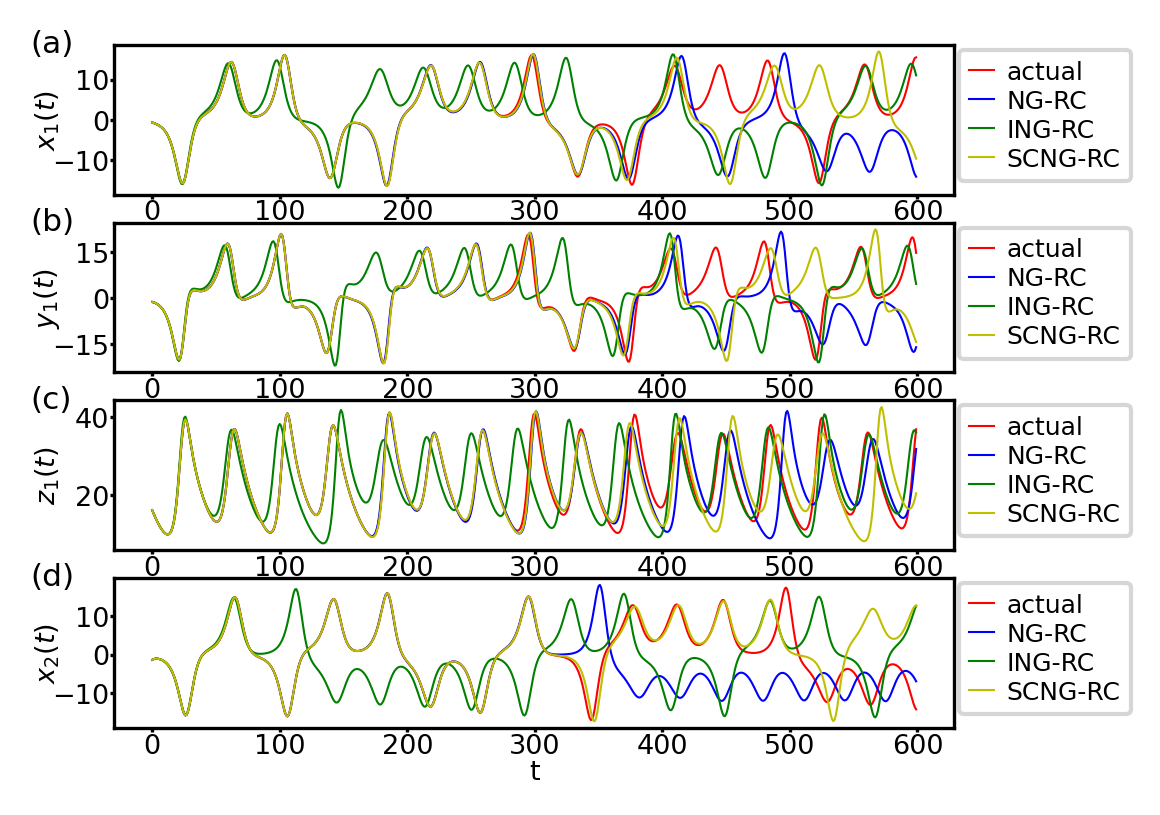

In [51]:
fig=hutu11(0.5)
# fig.savefig('fig7_t.pdf',format='pdf', dpi=300, bbox_inches='tight')

Text(2, 17.85, 'SCNG-RC')

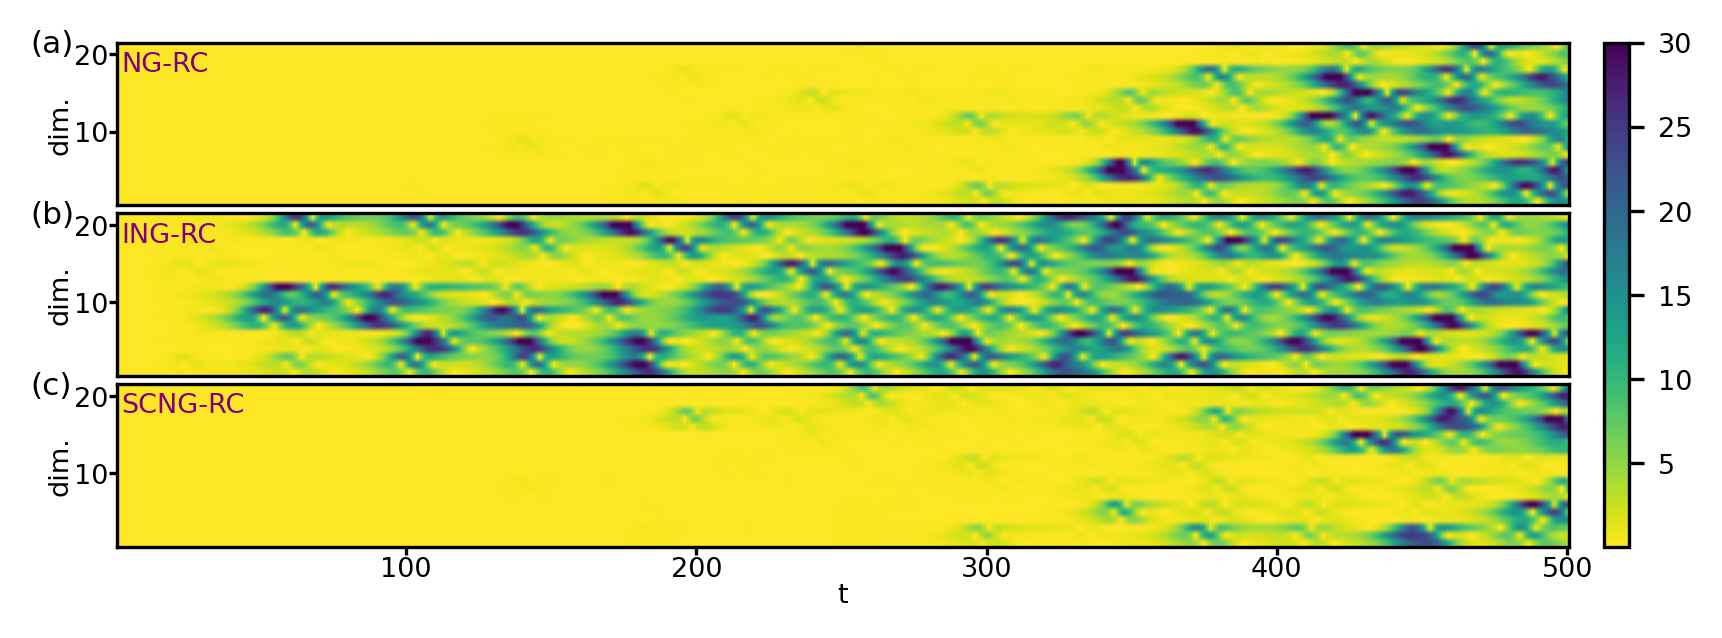

In [52]:
wucha1=np.abs(yc1[100:1100,:]*suo-xx2[:1000,:])
wucha2=np.abs(yc2[100:1100,:]*suo-xx2[:1000,:])
wucha3=np.abs(yct[100:1100,:]*suo-xx2[:1000,:])
l1,l2=wucha1.shape
llsh=500
vmax1=30
plt.rcParams.update({'font.size':6.5})
# plt.imshow()
fig, axs = plt.subplots(3,1,dpi=300,figsize=(17/2.54,5/2.54))
im = axs[0].imshow(wucha1[:llsh,:].T, cmap='viridis_r',vmax=vmax1,origin='lower',aspect="auto",
                   extent=[0.5, llsh+0.5,0.5, l2+0.5 ])
# cbar = ax1.figure.colorbar(im,ax=axs[0],pad=0.05)
im = axs[1].imshow(wucha2[:llsh,:].T, cmap='viridis_r',vmax=vmax1,origin='lower',aspect="auto",
                   extent=[0.5,llsh+0.5,0.5, l2+0.5 ])
# cbar = ax1.figure.colorbar(im,ax=axs[1],pad=0.05)
im = axs[2].imshow(wucha3[:llsh,:].T, cmap='viridis_r',vmax=vmax1,origin='lower',aspect="auto",
                   extent=[0.5,llsh+0.5,0.5, l2+0.5 ])
labelpad1=-0
for ii in range(3):
    axs[ii].set_ylabel(r'dim.',labelpad=labelpad1)
    if ii!=2:
        axs[ii].set_xticks([])
    axs[ii].tick_params(axis='both', labelsize=6.5,pad=0.2,length=2)
    # axs[ii].axis('off')
axs[2].set_xlabel('t',labelpad=0)
axs[0].set_title("(a)",loc='left',va='baseline', fontsize=7.5, pad=0.04,x=-0.06,y=0.94)
axs[1].set_title("(b)",loc='left',va='baseline', fontsize=7.5, pad=0.04,x=-0.06,y=0.94)
axs[2].set_title("(c)",loc='left',va='baseline', fontsize=7.5, pad=0.04,x=-0.06,y=0.94)
plt.subplots_adjust(top=0.967,
bottom=0.113,
left=0.083,
right=0.954,
hspace=0.05,
wspace=0.2)
# plt.tight_layout()
cbar = fig.colorbar(im,ax=axs,pad=0.02)
axs[0].text(2,l2-0.15*l2,'NG-RC',color='purple',fontsize=6.5)
axs[1].text(2,l2-0.15*l2,'ING-RC',color='purple',fontsize=6.5)
axs[2].text(2,l2-0.15*l2,'SCNG-RC',color='purple',fontsize=6.5)
# plt.savefig('fig7g.pdf', bbox_inches='tight')